          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -73.999481   
2                1        -73.979027        40.763939         -74.005333   
3                1        -74.010040        40.719971         -74.012268   
4                1        -73.973053        40.793209         -73.972923   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.765602                  N            455  
1         40.731

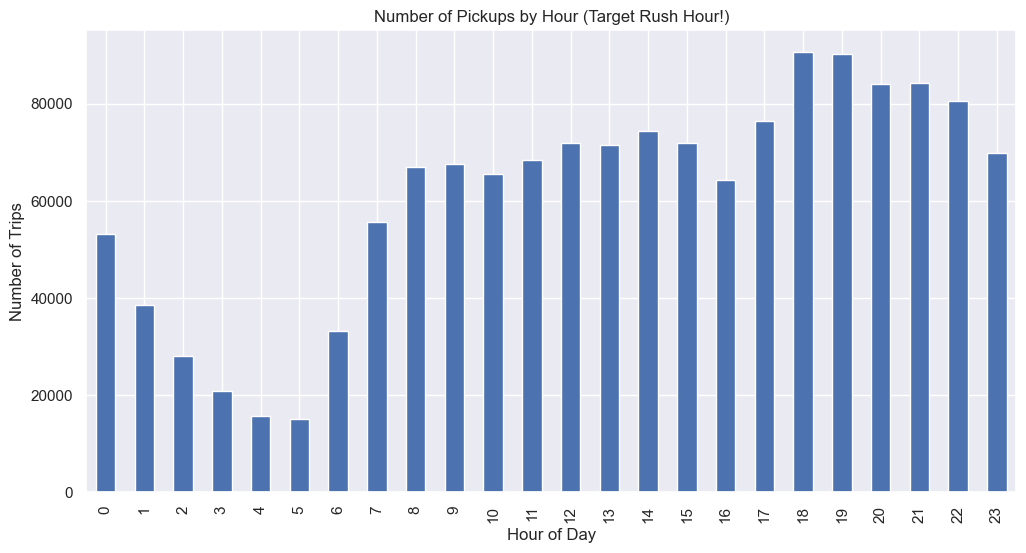

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Read the dataset (make sure the path is correct)
df = pd.read_csv("NYC_taxi_trip_train.csv")

# Basic data overview
print(df.head())
print(df.info())
print(df.describe())

# Convert time columns to datetime format
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Create additional time-based columns
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6

# Number of trips by hour (to identify rush hours)
hourly_counts = df['pickup_hour'].value_counts().sort_index()
hourly_counts.plot(kind='bar')
plt.title("Number of Pickups by Hour (Target Rush Hour!)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()


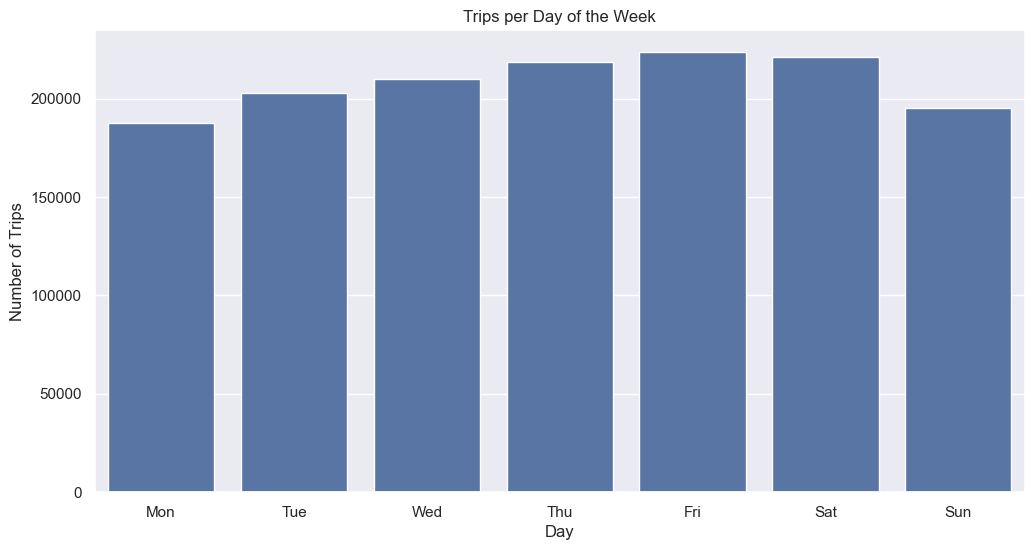

In [2]:
# analyze weekday
weekday_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['pickup_day'] = df['pickup_dayofweek'].map(weekday_map)

sns.countplot(data=df, x='pickup_day', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title("Trips per Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.show()



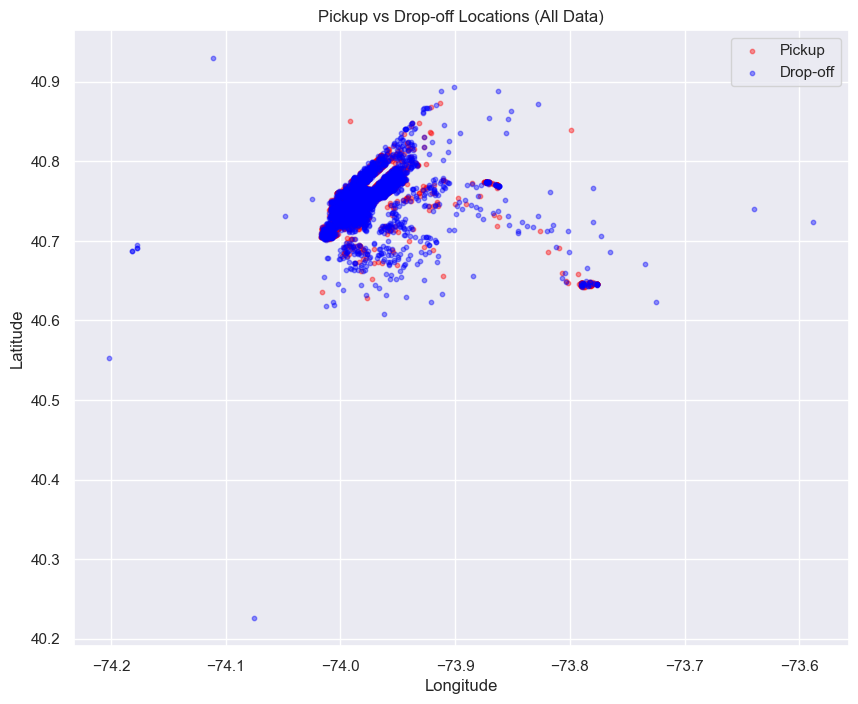

In [6]:
import matplotlib.pyplot as plt

# Optional: sample to reduce overplotting if data is large
pickup_sample = df.sample(n=3000, random_state=42)
dropoff_sample = df.sample(n=3000, random_state=43)

# Plot pickup and drop-off points together
plt.figure(figsize=(10, 8))
plt.scatter(pickup_sample['pickup_longitude'], pickup_sample['pickup_latitude'],
            s=10, alpha=0.4, c='red', label='Pickup')
plt.scatter(dropoff_sample['dropoff_longitude'], dropoff_sample['dropoff_latitude'],
            s=10, alpha=0.4, c='blue', label='Drop-off')

plt.title("Pickup vs Drop-off Locations (All Data)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()
